
# CT5120 Assignment 2 (Total 100 marks)




---
# **Task**

Please complete this task and **upload your answers to Canvas as a PDF ONLY with saved outputs**.  

📅 ***Deadline:*** **23:59** on **, November 21st 2025**  (Ireland Time)

⚠️ ***Late submissions*** will be penalised by **1% per day (For one week until November 27th 2025)**. Submission after this deadline will not be considered.


👤 This is an ***individual assignment*** and your work must be your own.  

**<font color="red">Strictly no Generative AI</font> : Do the assignment by yourself, write codes and answers fully in your own words without using AI tools.**  

<font color="red">**Note:** You must disable the AI features on Google Colab before working on this assignment.  
  
You can follow this video guide: [How to disable AI in Colab](https://youtu.be/qrGZv8nPh1o)</font>  


You may use libraries such as **Scikit-Learn** to complete this assignment.

⚠️ **Important:**  
- Make sure you fill in your **Name** and **Student ID** by running the below cell.  
- Do **not** modify any other cells in this notebook except those explicitly marked with  
  **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`**.  
- Ensure that all cells run successfully before submission.  
- We recommend using **Google Colab** to avoid any dependency issues.  



**Student Details**

In [54]:
# Enter your details below
NAME = input("Student Name   : ")
STUDENT_ID = input("Student ID     : ")

print(f"Student Name   : {NAME}")
print(f"Student ID     : {STUDENT_ID}")

Student Name   : Karthik Subramanya Ballal
Student ID     : 25242055


##  Data Explanation

In this assignment, you will build a **multi-label emotion detection** system for English texts.  
Each short text may express **zero, one, or multiple** emotions from the following fixed set:

> **Emotion labels:** `anger, fear, joy, sadness, surprise`



---

###  Dataset Structure

All files are located in the `./data/` directory.  
Each file is in **CSV format** with a header row. The columns differ slightly depending on whether the file includes labels.

| File | Columns | Description |
|------|----------|-------------|
| `train.csv` | `id,text,anger,fear,joy,sadness,surprise` | Training data.  |
| `dev.csv` | `id,text,anger,fear,joy,sadness,surprise` | validation data. |
| `test.csv` | `id,text` | Test data for which you will predict the six label columns. |

---

###  Example Row from `train.csv`


id,text,anger,fear,joy,sadness,surprise

eng_train_track_a_00001,"Colorado, middle of nowhere.",0,1,0,0,1,0

id → A unique identifier for the text sample (eng_train_track_a_00001).

text → The actual content to analyze ("Colorado, middle of nowhere.").

anger → 0 → the model (or annotators) determined anger is not present.

fear → 0 → no indication of fear.

joy → 0 → no joy detected.

sadness → 1 → sadness is expressed.

surprise → 0 → surprise is not expressed.




# Summary



In this assignment, you will build a **prompt-based emotion detection system** using a pretrained language model.  
The goal is to explore how different prompting strategies, from zero-shot to few-shot and beyond, affect performance on emotion classification.

You will complete the following tasks:
1. Load and Visualize the dataset.

2. Zero-Shot Prompting and Evaluation  
   - Load a small instruction-tuned model (e.g., `google/flan-t5-small`).  
   - Write a clear prompt that identifies which emotions appear in a given text.  
   - Apply your prompt to the development set and evaluate performance using **Precision**, **Recall**, and **Weighted F1-score**.  
   

3. Few-Shot Prompting and Evaluation
   - Extend your prompt by adding 3 to 5 labeled examples that illustrate how emotions are expressed.  
   - Reuse the same model and evaluation procedure.  
   - Compare results with the zero-shot version and interpret the improvements or remaining challenges.

4. Improvement and Evaluation
   - Implement one improvement of your choice to enhance emotion prediction.  
   - Evaluate the approach with the same metrics and summarize the effect of your changes.  
   



  




# Importing Libraries and Dataset


In [55]:
import os
import random
import warnings
import requests
from io import StringIO
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [56]:

# Load the dataset

def download_file_from_google_drive(file_id):
    """
    Downloads a CSV file from Google Drive using its file_id
    and returns the content as text.
    """
    URL = "https://drive.google.com/uc?export=download&id=" + file_id
    response = requests.get(URL)
    response.raise_for_status()
    return response.text


file_id_train = "1tQA_tKs0SzjIlOWWlIfblZcdiGU6S8b5"
file_id_dev   = "1ioGJH1xHXywX2xO3bxt-1hscAD6LoIwC"
file_id_test  = "1vHdpJe7lb0tFkx8dd18q0nNi40nqTRUh"


# Read CSVs directly into pandas
train_df = pd.read_csv(StringIO(download_file_from_google_drive(file_id_train)))
dev_df   = pd.read_csv(StringIO(download_file_from_google_drive(file_id_dev)))
test_df  = pd.read_csv(StringIO(download_file_from_google_drive(file_id_test)))

# train_df = pd.read_csv('/content/train.csv')
# dev_df  = pd.read_csv('/content/validation.csv')
# test_df  = pd.read_csv('/content/test.csv')

# Print dataset shapes
print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]



Train shape: (2143, 7)
Dev shape: (115, 7)
Test shape: (621, 7)


Take a look at the columns, and shape of the dataset.

In [ ]:
# An example text to be used later as a sample text
train_df["text"][9]

'Hondas are notoriously great cars for long trips for their dependability and great gas mileage.'

In [5]:
train_df.head(10)

,id,text,anger,fear,joy,sadness,surprise
0,eng_train_track_a_00001,"Colorado, middle of nowhere.",0,1,0,0,1
1,eng_train_track_a_00002,This involved swimming a pretty large lake tha...,0,1,0,0,0
2,eng_train_track_a_00003,It was one of my most shameful experiences.,0,1,0,1,0
3,eng_train_track_a_00004,"After all, I had vegetables coming out my ears...",0,0,0,0,0
4,eng_train_track_a_00005,Then the screaming started.,0,1,0,1,1
5,eng_train_track_a_00006,"They don't fear death, and it seems they belie...",0,1,0,0,1
6,eng_train_track_a_00007,You know what happens when I get one of these ...,1,1,0,0,0
7,eng_train_track_a_00008,My stomach even started giving me fits.,0,1,0,1,0
8,eng_train_track_a_00009,"Well, as we're bowling, my dinner began to not...",0,1,0,0,0
9,eng_train_track_a_00010,Hondas are notoriously great cars for long tri...,0,0,1,0,0


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2143 entries, 0 to 2142
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2143 non-null   object
 1   text      2143 non-null   object
 2   anger     2143 non-null   int64 
 3   fear      2143 non-null   int64 
 4   joy       2143 non-null   int64 
 5   sadness   2143 non-null   int64 
 6   surprise  2143 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 117.3+ KB


#Task 1. Data Exploration


### Data Visualization (10)
Plot a histogram illustrating the frequency of each emotion label in the training dataset.

Emotion Label Frequencies:
fear        1273
sadness      675
surprise     645
joy          527
anger        259
dtype: int64


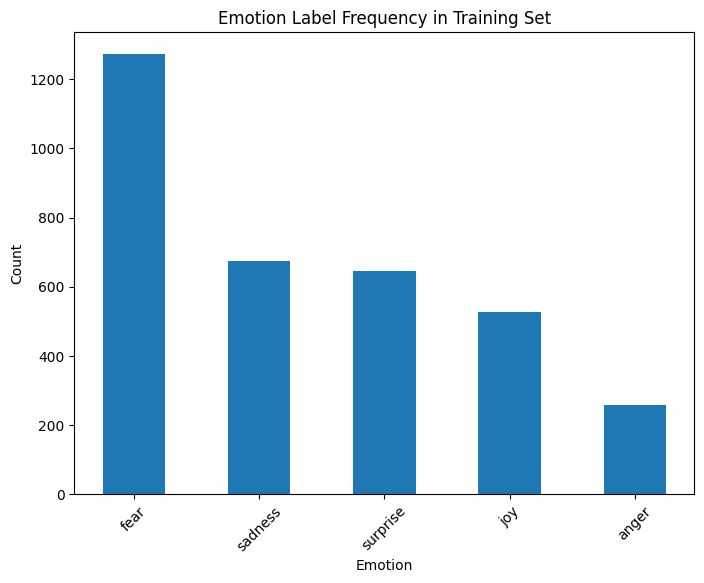

In [7]:
def data_exploration(train_df):
    """
    TODO:
    - Count how many times each emotion label appears in the training set.
    - Plot a bar chart of label frequencies (emotion on x-axis, count on y-axis).

    """
    # YOUR CODE HERE
    df = pd.Series({
        "anger": train_df["anger"].sum(),
        "fear": train_df["fear"].sum(),
        "joy": train_df["joy"].sum(),
        "sadness": train_df["sadness"].sum(),
        "surprise": train_df["surprise"].sum()
    })

    df.sort_values(ascending = False, inplace=True)

    print("Emotion Label Frequencies:")
    print(df)
    
    plt.figure(figsize=(8,6))
    plt.bar(df.keys(), df.values, width = 0.5)
    plt.xticks(rotation=45)
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.title("Emotion Label Frequency in Training Set")
    plt.show()
    # raise NotImplementedError()  # comment this line once you entered your code



data_exploration(train_df)

Emotion Label Frequencies:
fear        1273
sadness      675
surprise     645
joy          527
anger        259
dtype: int64


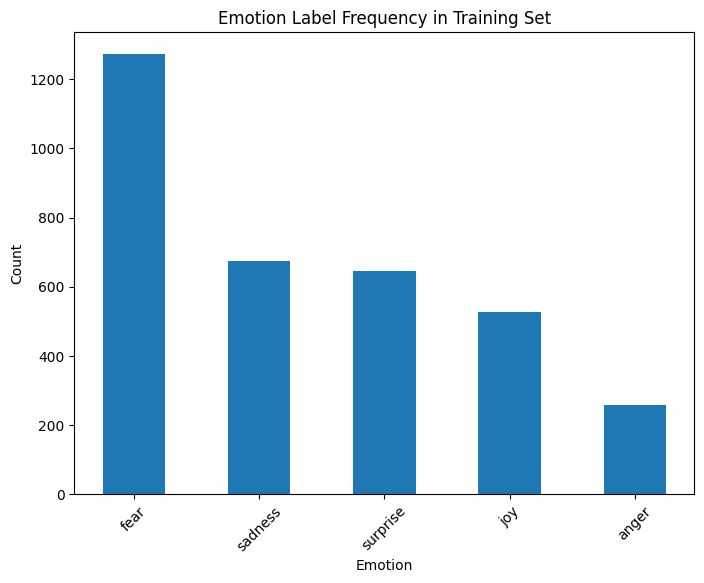

In [8]:
data_exploration(train_df)


#Task 2. Zero shot prompting

### Task 2A. Zero-Shot Prompting and Evaluation (10 marks)

In this step, you will load a **small instruction-tuned language model** (e.g., `google/flan-t5-small` or any other pretrained model you find appropriate) and test whether it can follow a **basic emotion classification prompt**.

You will:
- Write a clear prompt that lists all five emotions (`anger`, `fear`, `joy`, `sadness`, `surprise`)  
  and asks the model to identify which ones are expressed in a short text.  
- Generate responses for a few example sentences to see how the model interprets your instructions.  
  
Compare a few prompt variations and determine which one performs best.

**Tip:** The exact phrasing of your prompt can make a big difference.  
Try different formats — e.g., *“Which of the following emotions apply?”* vs. *“Classify the emotions present (output only labels)”* —  
and observe how they affect accuracy.  
Your goal is to find the **most effective prompt** for emotion detection in a zero-shot setup.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-small"  # or any other instruction-tuned model you find appropriate

print("Loading model:", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("Model and tokenizer loaded successfully.")


Loading model: google/flan-t5-small
Model and tokenizer loaded successfully.


In [53]:

def test_zero_shot_prompt(sample_text):
    """
    TODO:
    - Write a short prompt that asks the model which emotions appear in a given text.
    - Use the globally loaded model and tokenizer (do not reload them).
    - Generate the model's response for one sample text.
    - Print both the prompt and the model's response clearly.
    """
    # YOUR CODE HERE
    EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

    predictions = []

    print("Sample text:")
    print(sample_text)
    print("\nModel predictions:\n")

    prompt = (
        "Classify Emotions\n"
        "Given the text, identify emotions that apply.\n"
        "Possible emotions: anger, fear, joy, sadness, surprise.\n"
        f"Text: \"{sample_text}\"\n"
        "Emotions:"
    )

    inputs = tokenizer(prompt, return_tensors="pt")
    out = model.generate(**inputs, max_length=100)
    resp = tokenizer.decode(out[0], skip_special_tokens=True)

    print(f"{EMOTIONS}: {resp}")

    for emo in EMOTIONS:
        if emo in resp:
            predictions.append(1)
        else:
            predictions.append(0)
    
    return predictions

    # raise NotImplementedError()  # comment this line once you enter your code


# Example call
sample_text = "Hondas are notoriously great cars for long trips for their dependability and great gas mileage."
test_zero_shot_prompt(sample_text)


Sample text:
Hondas are notoriously great cars for long trips for their dependability and great gas mileage.

Model predictions:

['anger', 'fear', 'joy', 'sadness', 'surprise']: joy


[0, 0, 1, 0, 0]

### Task 2B. Evaluate the Zero-Shot Methodology (10 marks)


- Implement a function that runs your zero-shot prompt on each text in the test set.  
- Compare the predicted emotions against the true labels.  
- Compute and report **Precision**, **Recall**, and **Weighted F1-score** across all five emotions.  




In [33]:

def zero_shot_prompt(sample_text):
    """
    TODO:
    - Write a short prompt that asks the model which emotions appear in a given text.
    - Use the globally loaded model and tokenizer (do not reload them).
    - Generate the model's response for one sample text.
    - Print both the prompt and the model's response clearly.
    """
    # YOUR CODE HERE
    EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

    predictions = []

    prompt = (
        "Classify Emotions\n"
        "Given the text, identify emotions that apply.\n"
        "Possible emotions: anger, fear, joy, sadness, surprise.\n"
        f"Text: \"{sample_text}\"\n"
        "Emotions:"
    )

    inputs = tokenizer(prompt, return_tensors="pt")
    out = model.generate(**inputs, max_length=100)
    resp = tokenizer.decode(out[0], skip_special_tokens=True)

    resp = resp.lower()

    for emo in EMOTIONS:
        predictions.append(1 if emo in resp else 0)
    
    return predictions


In [ ]:

from sklearn.metrics import classification_report, accuracy_score
def evaluate_zero_shot():
    """
    TODO:
    - For each text in test_df:
        * Generate the model's response.
        * Convert the response into a binary prediction for each emotion (0 or 1).
    - Compare predictions with the true labels.
    - Compute Precision, Recall, and Weighted F1-score.
    return scores
    """
    # YOUR CODE HERE
    all_preds = []
    all_labels = []

    for _, row in test_df.iterrows():
        text = row["text"]

        true = [row[e] for e in EMOTIONS]

        pred = zero_shot_prompt(text)

        all_labels.append(true)
        all_preds.append(pred)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    report = classification_report(
        all_labels, all_preds, target_names=EMOTIONS, zero_division=0
    )

    acc = accuracy_score(all_labels, all_preds)
    print("\n=== Zero-shot Evaluation Report ===")
    print(report)
    print(f"Overall Accuracy: {acc:.4f}")
    # raise NotImplementedError()  # comment this line once you entered your code

# Example call
evaluate_zero_shot()



=== Zero-shot Evaluation Report ===
              precision    recall  f1-score   support

       anger       0.33      0.41      0.36        74
        fear       1.00      0.05      0.09       337
         joy       0.54      0.54      0.54       147
     sadness       0.51      0.69      0.58       201
    surprise       0.59      0.28      0.38       194

   micro avg       0.51      0.33      0.40       953
   macro avg       0.59      0.39      0.39       953
weighted avg       0.69      0.33      0.34       953
 samples avg       0.51      0.32      0.38       953

Overall Accuracy: 0.1739


### Task 2C. Interpretation Questions (10 marks)



1.  Which emotions were predicted most accurately, and which were the most difficult? Why do you think this happened?

2. How well did the model follow your prompt instructions? Provide one example where it worked well or failed.


Answer above questions briefly (less than 250 words).

```
In the zero-shot approach, emotions such as joy, sadness, and surprise achieved the highest F1 scores, reflecting more accurate predictions compared to anger and fear. Notably, fear showed the lowest F1 score, with perfect precision (1.0) but very low recall (0.05), indicating the model frequently missed instances expressing fear. This may stem from the complexity of texts containing multiple emotions, while the model appears limited to identifying only a single dominant emotion per instance.

Although the model demonstrated some understanding that emotion classification is required, its ability to detect multiple emotions within a single text remains limited. This constraint likely contributed to the lower overall performance and relatively modest weighted-average F1 scores. The overall accuracy of approximately 0.17 further highlights the challenge. For example, in the provided sample text, the model correctly identified joy, but it may misclassify fear-related expressions as sadness, which could explain the poor recall for fear.
```

# Task 3. Few Shot Prompting

### Task 3A. Few-Shot Model Setup (10 marks)

Extend your zero-shot system by adding **3–5 labeled examples** to the prompt before the query text.  
Use the same model and tokenizer already loaded earlier (Use the same model that you used for Task 1).  



In [ ]:


def test_few_shot_prompt(sample_text):
    """
    TODO:
    - Reuse the already loaded model and tokenizer.
    - Create a prompt that includes 3-5 labeled examples, followed by a new query text.
    - Generate the model's output for one sample text.
    - Print the full prompt and the model's response.
    """
    # YOUR CODE HERE
    EMONTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

    predictions = []

    EXAMPLES = (
        "Example 1:\n"
        "Text: \"I was thrilled to finally get the job, but a little scared about moving.\"\n"
        "Emotions: joy, fear\n\n"
        
        "Example 2:\n"
        "Text: \"I can't believe he said that to me! I'm furious and shocked.\"\n"
        "Emotions: anger, surprise\n\n"
        
        "Example 3:\n"
        "Text: \"Missing home always makes me feel so down and worried.\"\n"
        "Emotions: sadness, fear\n\n"
    )

    prompt = (
        "You are an emotion classification system.\n"
        "Given the text, identify *all* emotions that apply.\n"
        "Possible emotions: anger, fear, joy, sadness, surprise.\n"
        "Return a comma-separated list of all matching emotions.\n\n"
        f"{EXAMPLES}"
        "Now classify the following text:\n"
        f"Text: \"{sample_text}\"\n"
        "Emotions:"
    )

    inputs  = tokenizer(prompt, return_tensors="pt")
    output = model.generate(**inputs, max_length=100)
    resp = tokenizer.decode(output[0], skip_special_tokens=True)
    resp = resp.lower()

    for emo in EMOTIONS:
        predictions.append(1 if emo in resp else 0)
    
    print("Full Prompt:")
    print(prompt)
    print("\nModel Response:")
    print(resp)

    return predictions
    # raise NotImplementedError()  # comment this line once you enter your code

# Example call
sample_text = "I was ecstatic about the surprise party, but also a bit anxious about the speeches."
test_few_shot_prompt(sample_text)


Full Prompt:
You are an emotion classification system.
Given the text, identify *all* emotions that apply.
Possible emotions: anger, fear, joy, sadness, surprise.
Return a comma-separated list of all matching emotions.

Example 1:
Text: "I was thrilled to finally get the job, but a little scared about moving."
Emotions: joy, fear

Example 2:
Text: "I can't believe he said that to me! I'm furious and shocked."
Emotions: anger, surprise

Example 3:
Text: "Missing home always makes me feel so down and worried."
Emotions: sadness, fear

Now classify the following text:
Text: "I was ecstatic about the surprise party, but also a bit anxious about the speeches."
Emotions:

Model Response:
surprise


[0, 0, 0, 0, 1]

### Section 3B — Evaluate the Few-Shot Methodology (10 marks)

Now apply your **few-shot prompt** to the test set and measure its performance.  
This step helps you understand whether providing a few labeled examples improves accuracy compared to zero-shot prompting.

You will:
- Apply your few-shot prompt to each text in the test set.  
- Convert the model's responses into binary emotion predictions.  
- Compute and report Precision, Recall and Weighted F1-score  across all five emotions.  
- Compare the results with your zero-shot evaluation.


In [ ]:
def few_shot_prompt(sample_text):
    """
    TODO:
    - Reuse the already loaded model and tokenizer.
    - Create a prompt that includes 3-5 labeled examples, followed by a new query text.
    - Generate the model's output for one sample text.
    - Print the full prompt and the model's response.
    """
    # YOUR CODE HERE

    predictions = []

    EXAMPLES = """
        Example 1:
        Text: "I can't stop smiling today. Everything feels wonderful!"
        Emotions: joy

        Example 2:
        Text: "I am terrified someone is following me."
        Emotions: fear

        Example 3:
        Text: "I feel so sad and empty inside."
        Emotions: sadness

        Example 4:
        Text: "I can't believe you broke my laptop!"
        Emotions: anger

        Example 5:
        Text: "Wow! I didn't expect that at all!"
        Emotions: surprise
    """

    prompt = (
        "You are an emotion classification system.\n"
        "Identify which all emotions apply.\n"
        "Possible emotions: anger, fear, joy, sadness, surprise.\n\n"
        + EXAMPLES +
        f"\nNow classify the following text:\nText: \"{sample_text}\"\nEmotions:"
    )

    inputs  = tokenizer(prompt, return_tensors="pt")
    output = model.generate(**inputs, max_length=100)
    resp = tokenizer.decode(output[0], skip_special_tokens=True)
    resp = resp.lower()

    for emo in EMOTIONS:
        predictions.append(1 if emo in resp else 0)

    return predictions

In [ ]:


def evaluate_few_shot():
    """
    TODO:
    - For each text in test_df:
        * Build a few-shot prompt that includes the provided examples followed by the target text.
        * Generate the model's response using the loaded model and tokenizer.
        * Convert the response into binary predictions for each emotion (0 or 1).
    - Compare predictions with the true labels.
    - Compute and print macro Precision, Recall, and Weighted F1-score.

    """
    # YOUR CODE HERE
    all_pred = []
    all_labels = []

    for _, row in test_df.iterrows():
        text = row["text"]

        true = [row[e] for e in EMOTIONS]

        pred = few_shot_prompt(text)

        all_labels.append(true)
        all_pred.append(pred)

    all_labels = np.array(all_labels)
    all_pred = np.array(all_pred)

    # sklearn classification report
    report = classification_report(
        all_labels, all_pred, target_names=EMOTIONS, zero_division=0
    )
    print("\n=== Few-shot Evaluation Report ===")
    print(report)
    acc = accuracy_score(all_labels, all_pred)
    print(f"Overall Accuracy: {acc:.4f}")
    # raise NotImplementedError()  # comment this line once you enter your code

# Example call
evaluate_few_shot()



=== Few-shot Evaluation Report ===
              precision    recall  f1-score   support

       anger       0.85      0.15      0.25        74
        fear       0.94      0.05      0.10       337
         joy       0.82      0.06      0.11       147
     sadness       0.58      0.57      0.57       201
    surprise       0.38      0.75      0.51       194

   micro avg       0.48      0.31      0.38       953
   macro avg       0.71      0.32      0.31       953
weighted avg       0.73      0.31      0.29       953
 samples avg       0.48      0.28      0.34       953

Overall Accuracy: 0.1224


### Section 3C — Interpretation Questions (10 marks)



1. How did the few-shot results differ from your zero-shot results? Which emotions benefited the most?

2. How did the chosen few-shot examples influence the model’s predictions? Provide one observation or example.

Answer above questions briefly (less than 250 words).

```
In the few-shot method, I provided the model with some baic examples that express monotone emotions, emotions such as surprise and fear benefitted with the new approach with surprise having a great change in its f1 score indicating that more instances of surprise were correctly pointed to. While we can also see that there is a severe drop for joy emotion which is likely because of sentences that express both joy and surprise which were previously classified as joy may have shifted to surprise and thus explaining a sharp drop in recall for joy.

The examples initially were chose to deomonstrate multiple emotions but the model terribly fail to detect emotions and thus simple and straight-forward examples were taken to indicate single emotions for model to get indicators of an emotion. While it did work for the model but because of the models capacity to only output a single emotion for an instance it fails to provide a better score overall, with some emotions taking a hit to their predictions. Approach of asking model whether this sentence demonstrates a specific emotion was also implemented to simulate a multi emotion classification which worked to some extent but greatly reduced recalls of all emotions as the model started hallucinating in the process. Thus for a small model, a simole method was approached.
```



#Task 4. Implement An Improvement



### Task 4A — Classification Improvement (10 marks)

In this final task, you will implement an improvement to enhance the emotion classification system.  
You may build upon your previous zero-shot or few-shot approach, but the method should represent a meaningful extension or refinement.  
This is your opportunity to explore how prompting strategies or model interactions can lead to better results.

You should:

1. **Describe** your idea briefly in a Markdown cell (what you’re trying to improve and why).  
2. **Implement** your approach in code.  
  



In [ ]:
def implement_improvement(sample_text):
    """
    TODO:
    - Apply your chosen improvement method to the existing system.
    - Generate predictions for the test set.

    """
    # YOUR CODE HERE
    EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

    prompt = (
            "You are an emotion classification system.\n"
            "Given the text below, first give a very brief step-by-step reasoning (1-3 short sentences) identifying cues in the sentence that support particular emotions.\n"
            "Then on a single line output the FINAL labels only, comma-separated, chosen from: anger, fear, joy, sadness, surprise.\n"
            "Do not include any other words on the final labels line — just the labels separated by commas (or 'none' if no emotion applies).\n\n"
            f"Text: \"{sample_text}\"\n\n"
            "Reasoning:"
        )

    inputs = tokenizer(prompt, return_tensors="pt")
    out = model.generate(**inputs, max_length=50)
    resp = tokenizer.decode(out[0], skip_special_tokens=True).lower().strip()

    pred_vec = [1 if emo in resp else 0 for emo in EMOTIONS]
    return pred_vec
    # raise NotImplementedError()  # comment this line once you enter your code

# Example call
sample_text = "I was ecstatic about the surprise party, but also a bit anxious about the speeches."
implement_improvement(sample_text)


[0, 0, 0, 0, 1]

### Task 4B— Evaluation of Your Improved Method (10 marks)

Now evaluate your custom improvement using the same metrics as before, **Precision**, **Recall**, and **Weighted F1-score**.  
This helps determine whether your change led to measurable gains compared to your zero-shot and few-shot results.  



In [50]:


def evaluate_few_shot():
    """
    TODO:
    - Compute evaluation metrics for your improved model:
        * Precision
        * Recall
        * Weighted F1-score
    - Print the results clearly for comparison with earlier methods.

    """
    # YOUR CODE HERE
    all_pred = []
    all_labels = []

    for _, row in test_df.iterrows():
        text = row["text"]
        true = [row[e] for e in EMOTIONS]

        pred = implement_improvement(text)

        all_labels.append(true)
        all_pred.append(pred)

    all_labels = np.array(all_labels)
    all_pred = np.array(all_pred)

    report = classification_report(
        all_labels, all_pred, target_names=EMOTIONS, zero_division=0
    )
    print("\n=== Improved Few-Shot Prompt Evaluation ===")
    print(report)
    # raise NotImplementedError()  # comment this line once you enter your code

# Example call
evaluate_few_shot()



=== Improved Few-Shot Prompt Evaluation ===
              precision    recall  f1-score   support

       anger       0.22      0.62      0.33        74
        fear       0.64      0.42      0.50       337
         joy       0.19      0.12      0.14       147
     sadness       0.51      0.46      0.48       201
    surprise       0.31      0.57      0.40       194

   micro avg       0.39      0.43      0.40       953
   macro avg       0.37      0.44      0.37       953
weighted avg       0.44      0.43      0.41       953
 samples avg       0.24      0.37      0.25       953



### Task 4C — Interpretation Questions (10 marks)



1. How did your modification affect the model’s performance compared to the few-shot and zero-shot results?

2.  Why do you think your improvement helped (or didn’t help)? Support your answer with examples or metric trends.

Answer above questions briefly (less than 250 words).

```
The improvement in this approach is introduces the chain of thought framework for emotion classification. This approach by far has exceeded immensely compared to few-shot method and fairly outperformed zero-shot while strictly looking at the weighted average f1 score which represents a balanced evaluation of the model performance.

The Chain of thought helps us to create a base logic for the model to work upon. With a fix set of rules to follwo the model is refrained from hallucinating to a certain degree. Key phrases such as “step-by-step,” “reasoning,” and “identifying cues” guide the model to carefully analyze each sentence sequentially, leading to more accurate emotion predictions. Compared to previous approaches, the F1 scores across all emotions are more balanced, with notable improvements in detecting “fear” and “surprise”. From the initial anlaysis of the data we can see that there are more instances of fear in the dataset which aligns well with the model's enhanced performance.
```

